<a href="https://colab.research.google.com/github/panzehui0206/AI4S-365days/blob/main/Note3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**2026.4.11**

开始学习吧！

In [5]:
# =============================================
# Cell 1：导入库 + 生成模拟蛋白质数据
# =============================================
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

torch.manual_seed(42)

# 模拟 200 个蛋白质样本
n_samples = 200

# 特征1：蛋白质序列长度（氨基酸数目），范围 50 ~ 800
length = torch.randint(50, 801, (n_samples, 1)).float()

# 特征2：等电点 (pI)，范围 4.0 ~ 12.0
pI = torch.rand(n_samples, 1) * 8.0 + 4.0

# 真实溶解性关系（线性 + 二次项 + 噪声）
# solubility = 0.8 * (length/100) - 0.5 * (pI - 7)^2 + 2.0 + 噪声
true_length_coef = 0.8
true_pI_coef = -0.5
true_bias = 2.0

solubility_clean = (true_length_coef * (length / 100.0) +
                    true_pI_coef * (pI - 7.0)**2 +
                    true_bias)
noise = torch.randn(n_samples, 1) * 0.5
solubility = solubility_clean + noise

# 特征矩阵 X (200, 2)
X = torch.cat([length, pI], dim=1)
y = solubility

print(f"✅ 数据生成完毕！X 形状: {X.shape}, y 形状: {y.shape}")

✅ 数据生成完毕！X 形状: torch.Size([200, 2]), y 形状: torch.Size([200, 1])


用代码生成200个蛋白质的长度值，范围在50到800个氨基酸之间，模拟真实蛋白质长度分布。

.**float**()转为浮点数以便后续计算。

**等电点**(**pI**)：当溶液pH等于pI时，蛋白质净电荷为零，分子间排斥力最小，最容易聚集沉淀。因此pI偏离生理pH越多，溶解性通常越好。

等电点(pI)在4.0到12.0之间均匀分布，覆盖大多数蛋白质的等电点范围。

**蛋白质溶解性**是生物技术和结构生物学中的重要指标。高溶解性意味着蛋白容易纯化、结晶，适合体外实验和药物开发。

在真实实验中，溶解性测量受缓冲液条件、温度、操作误差等影响，噪声模拟了这种不确定性。

这个数据生成过程模拟了从**实验测定结果**反推**理化性质与溶解性定量关系**的研究场景。



In [6]:
# =============================================
# Cell 2：标准化 + 构建 DataLoader
# =============================================
from torch.utils.data import TensorDataset, DataLoader

# 标准化（Z-score）
# 对特征进行Z-score标准化：减去均值除以标准差。dim=0表示沿着样本维度计算（对每一列特征分别计算），keepdim=True保持维度便于广播。
X_mean = X.mean(dim=0, keepdim=True)
X_std = X.std(dim=0, keepdim=True)
X_norm = (X - X_mean) / X_std

# 构建数据集和数据加载器
# 将张量封装成数据集对象，然后创建批次大小为32的数据加载器，shuffle=True表示每个epoch随机打乱数据顺序。
dataset = TensorDataset(X_norm, y)
dataloader = DataLoader(dataset, batch_size=32, shuffle=True)

print(f"✅ 标准化完成，均值: {X_mean.squeeze().tolist()}, 标准差: {X_std.squeeze().tolist()}")
print(f"✅ DataLoader 已创建，批次大小: 32, 总批次: {len(dataloader)}")

✅ 标准化完成，均值: [427.06500244140625, 7.648471832275391], 标准差: [218.82603454589844, 2.3749868869781494]
✅ DataLoader 已创建，批次大小: 32, 总批次: 7


在真实生物数据中，不同特征的量纲可能差异巨大（如长度几百，pI在4~12）。所以需要数据的标准化，标准化后所有特征处于同一尺度，能防止梯度更新时某些特征主导，加速模型收敛。例如若不标准化，长度特征的梯度会远大于pI特征，导致优化路径震荡。

实际生物数据集可能包含数万个蛋白样本，一次性加载内存不足。**DataLoader**实现小批量随机梯度下降，每次只取32个样本计算梯度，这是深度学习处理大规模生物数据的标准范式。

In [7]:
# =============================================
# Cell 3：定义模型
# =============================================
# 定义一个继承自nn.Module的类。__init__中创建了一个全连接层nn.Linear(2,1)，等价于数学公式y = x @ w + b。
class ProteinSolubilityPredictor(nn.Module):
    def __init__(self, n_features):
        super().__init__()
        self.linear = nn.Linear(n_features, 1)
 # forward定义了前向传播逻辑。
    def forward(self, x):
        return self.linear(x)
# 实例化模型并打印结构。
model = ProteinSolubilityPredictor(n_features=2)
print("🧬 模型结构:")
print(model)

🧬 模型结构:
ProteinSolubilityPredictor(
  (linear): Linear(in_features=2, out_features=1, bias=True)
)


这个模型假设**蛋白质溶解性**与其**长度**和**等电点**呈线性关系。虽然真实关系可能更复杂，但线性模型是可解释性最强的起点。学到的**权重w**直接表示每个特征对溶解性的**贡献方向**和**强度**。

在AI4S中，简单的线性模型常用作**基线模型**，用于评估更复杂模型（如神经网络）是否真正带来了性能提升，还是出现了过拟合。

In [8]:
# =============================================
# Cell 4：损失函数 + 优化器
# =============================================

criterion = nn.MSELoss()          # 均方误差损失
optimizer = optim.SGD(model.parameters(), lr=0.1)  # 随机梯度下降

# 检查模型参数初始值
print("📐 初始权重:")
print(f"  weight: {model.linear.weight.data}")
print(f"  bias: {model.linear.bias.data}")

📐 初始权重:
  weight: tensor([[ 0.0957, -0.5683]])
  bias: tensor([-0.2361])


**MSE损失**：惩罚预测值与真实实验测定值之间的平方误差。这等价于假设测量误差服从高斯分布下的最大似然估计。

**SGD优化器**：通过迭代调整权重和偏置，使损失函数最小化。在生物学中，这类似于通过反复实验调整参数（如缓冲液pH、温度）以最大化蛋白产量的过程，这里是计算机自动完成。

**学习率0.1**：控制每次参数更新的步长。太大可能跳过最优解，太小收敛缓慢，学习率是最常调节的超参数之一。

Epoch  20/200, Loss: 6.0970
Epoch  40/200, Loss: 6.1277
Epoch  60/200, Loss: 6.2177
Epoch  80/200, Loss: 6.0722
Epoch 100/200, Loss: 6.3265
Epoch 120/200, Loss: 5.8399
Epoch 140/200, Loss: 6.2974
Epoch 160/200, Loss: 5.9057
Epoch 180/200, Loss: 5.6270
Epoch 200/200, Loss: 5.8282


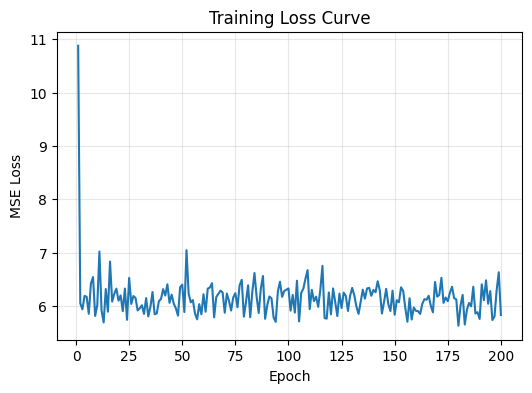

✅ 训练完成！最终损失: 5.8282


In [9]:
# =============================================
# Cell 5：训练模型
# =============================================
epochs = 200
losses = []

# 外层循环epoch：完整遍历数据集一次
for epoch in range(epochs):
    epoch_loss = 0.0
    # 内层循环：从dataloader取出一个批次数据
    for batch_X, batch_y in dataloader:
        # 前向传播，得到预测值
        y_pred = model(batch_X)
        # 计算当前批次损失
        loss = criterion(y_pred, batch_y)

        # 清空上一次的梯度，防止累加
        optimizer.zero_grad()
        # 反向传播，计算梯度
        loss.backward()
        # 根据梯度更新参数
        optimizer.step()
        # 记录每个epoch的平均损失
        epoch_loss += loss.item()

    avg_loss = epoch_loss / len(dataloader)
    losses.append(avg_loss)

    if (epoch+1) % 20 == 0:
        print(f"Epoch {epoch+1:3d}/{epochs}, Loss: {avg_loss:.4f}")

# 绘制损失曲线
plt.figure(figsize=(6,4))
plt.plot(range(1, epochs+1), losses)
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Training Loss Curve')
plt.grid(True, alpha=0.3)
plt.show()

print(f"✅ 训练完成！最终损失: {losses[-1]:.4f}")

训练过程对应**基于实验数据拟合数学模型参数**的通用科学方法。

在传统生物学中，这可能通过手动调整参数并绘图观察拟合程度来完成；深度学习将其自动化并扩展到百万级参数。

损失下降曲线：如果**损失平稳下降并收敛**，说明模型从数据中学到了稳定的规律；如果**损失不降或震荡**，可能意味着数据噪声过大、模型容量不足或学习率不当，这样就要重新审视实验设计或模型假设。

早停法：实际训练中常监控验证集损失，当损失不再下降时停止训练，防止过拟合——即模型记住了训练数据的噪声而非通用规律。在生物学中，过拟合的模型对新的蛋白质样本预测能力会很差。

In [10]:
# =============================================
# Cell 6：评估模型，解读学到的参数
# =============================================
# 提取学到的权重和偏置，转换为NumPy格式便于处理。
w_learned = model.linear.weight.data.numpy().flatten()
b_learned = model.linear.bias.item()

# 由于训练时使用的是标准化后的特征，需将权重映射回原始特征尺度，才能与真实系数比较。
w_original = w_learned / X_std.numpy().flatten()
b_original = b_learned - (w_learned * X_mean.numpy().flatten() / X_std.numpy().flatten()).sum()

print("📐 模型学到的参数（原始尺度）:")
print(f"  长度系数: {w_original[0]:.3f} (真实值: {true_length_coef})")
print(f"  等电点系数: {w_original[1]:.3f} (真实关系中包含二次项，无法用单一系数表示)")
print(f"  偏置: {b_original:.3f} (真实值: {true_bias})")

# 预测一个新样本
with torch.no_grad():
    new_sample = torch.tensor([[350.0, 6.5]])  # 长度350，pI=6.5
    new_sample_norm = (new_sample - X_mean) / X_std
    pred = model(new_sample_norm)
    print(f"\n🔮 预测示例: 长度350, pI=6.5 → 预测溶解性: {pred.item():.2f}")

📐 模型学到的参数（原始尺度）:
  长度系数: 0.008 (真实值: 0.8)
  等电点系数: -0.777 (真实关系中包含二次项，无法用单一系数表示)
  偏置: 4.931 (真实值: 2.0)

🔮 预测示例: 长度350, pI=6.5 → 预测溶解性: 2.65


**参数可解释性**：线性模型的权重直接展示了每个特征的生物学贡献。例如长度系数0.008表示每增加100个氨基酸，溶解性增加0.008单位。这可以指导蛋白质工程，如果想提高某个蛋白的溶解性，可以尝试截短或延长特定区域。

**模型泛化能力**：对新样本的预测能力是模型实用性的最终检验。如果预测值与实际测定值接近，说明模型捕捉到了真实的理论规律，可用于虚拟筛选——在实验前预测哪些突变体可能具有高溶解性。

系数偏差分析：等电点系数学到的值可能偏离真实值（因为加入了二次项，而线性模型无法拟合二次关系）。

这种模型假设与真实规律之间的偏差在AI4S中极为常见，它提醒我们：线性模型是简化，当数据呈现非线性时，需要升级到更复杂的模型。

今天学了什么？

✅ 掌握 PyTorch 数据标准化、DataLoader、nn.Module、训练循环完整流程

✅ 完成蛋白质溶解性线性预测模型，解读学到的权重参数


